# Tutorial 03 — Learning from Sequences: RNNs and LSTMs

### From Machine Learning to Foundation Models · Hands-On AI for Power & Energy Systems

> **Why are ordinary feed-forward networks insufficient for sequential data?**

---

## 1. Why this matters

Tutorials 01 and 02 never saw a time series. They saw a *table* whose columns
happened to be called `lag24` and `lag168`. A human decided which lags to
include, and the models had no idea that column 3 came one hour after column
2 — shuffle the columns and nothing changes.

That works, and it works well, right up to the point where you want the model
to transfer. A table of lags is specific to one sampling rate, one context
length and one feature list. A model that consumes the *sequence itself* is
not: it can be handed a longer history, a different site, or a different
variable. Every time-series foundation model in tutorial 09 works this way,
and this notebook is where the course stops hand-picking lags.

## 2. Historical context

Recurrent networks date to the late 1980s (Elman, Jordan). They were known to
be almost untrainable on long sequences, and Hochreiter's 1991 diploma thesis
and Bengio et al. (1994) explained why: gradients decay geometrically as they
are propagated back through time. The LSTM (Hochreiter & Schmidhuber, 1997)
was the fix, and it dominated sequence modelling for roughly twenty years —
machine translation, speech recognition, and energy forecasting alike — until
attention displaced it from 2017 onwards.

## 3. Learning objectives

By the end of this notebook you can:

- explain why a feed-forward network on a flattened window has no notion of
  order, and what that costs;
- implement an RNN cell and unroll it by hand;
- *measure* the vanishing-gradient problem rather than take it on faith;
- explain what the LSTM's gates and cell state do about it;
- distinguish sequence-to-one from sequence-to-sequence forecasting;
- compare persistence, linear autoregression, gradient boosting, an MLP and an
  LSTM on identical windows and interpret the result honestly.

In [1]:
from __future__ import annotations

import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from torch import nn

from ai_power_course import diagrams
from ai_power_course.config import fast_mode, scaled, set_seed
from ai_power_course.data import load_energy_data, make_windows, time_split
from ai_power_course.metrics import mae, point_metrics, rmse, skill_score
from ai_power_course.models.forecasters import LSTMForecaster, MLPForecaster, SimpleRNNForecaster
from ai_power_course.models.training import (
    Standardizer,
    TrainConfig,
    count_parameters,
    make_loader,
    predict,
    train_model,
)
from ai_power_course.plotting import COLORS, plot_forecast, plot_learning_curve, use_course_style
from ai_power_course.results import Leaderboard, leaderboard_table, record

warnings.filterwarnings("ignore", category=FutureWarning)
use_course_style()
set_seed()
torch.set_num_threads(4)
print(f"reduced (CI) configuration: {fast_mode()}")

reduced (CI) configuration: False


## 4. Theory

### The recurrent idea

Keep a hidden state and update it once per time step:

$$\mathbf{h}_t = \tanh(W_x \mathbf{x}_t + W_h \mathbf{h}_{t-1} + \mathbf{b}), \qquad
  \hat y = W_o \mathbf{h}_T$$

The same $W_x, W_h$ are used at every step. Two consequences follow, and both
matter for the foundation-model story:

1. **The parameter count does not depend on the sequence length.** A
   feed-forward network on a 168-hour window needs $168 \times d$ input
   weights; an RNN needs $d$, whatever the length. The same weights can be
   applied to a longer history.
2. **Order is built into the architecture**, not into the feature list.

### Why the gradient dies

Backpropagating from step $T$ to step $t$ multiplies $T-t$ Jacobians:

$$\frac{\partial \mathbf{h}_T}{\partial \mathbf{h}_t}
  = \prod_{k=t+1}^{T} W_h^\top \operatorname{diag}\!\big(1 - \mathbf{h}_k^2\big)$$

Since $|\tanh'| \le 1$, the product shrinks geometrically unless the spectral
radius of $W_h$ is very close to 1. If it exceeds 1 the gradient *explodes*
instead. There is no comfortable setting, which is the whole problem.

### What the LSTM changes

It adds a **cell state** $\mathbf{c}_t$ updated *additively*:

$$\mathbf{c}_t = f_t \odot \mathbf{c}_{t-1} + i_t \odot \tilde{\mathbf{c}}_t$$

With the forget gate $f_t$ near 1 the derivative $\partial c_t / \partial
c_{t-1}$ is near 1, so gradients can travel a long way without decaying. The
gates are learned, so the network decides for itself how long to remember.

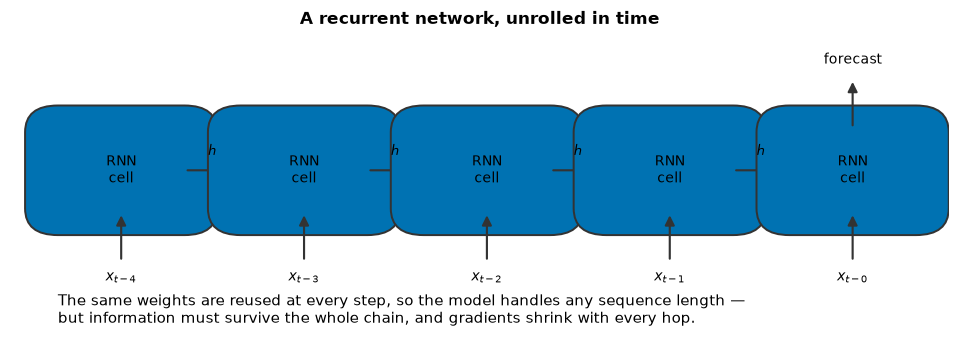

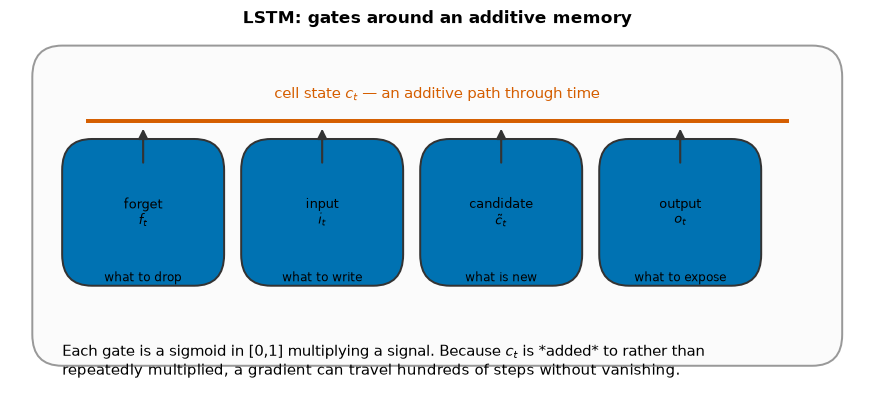

In [2]:
fig = diagrams.rnn_unrolled()
plt.show()
fig = diagrams.lstm_cell()
plt.show()

## 5. From scratch: unrolling an RNN by hand

Six lines. Everything else is bookkeeping.

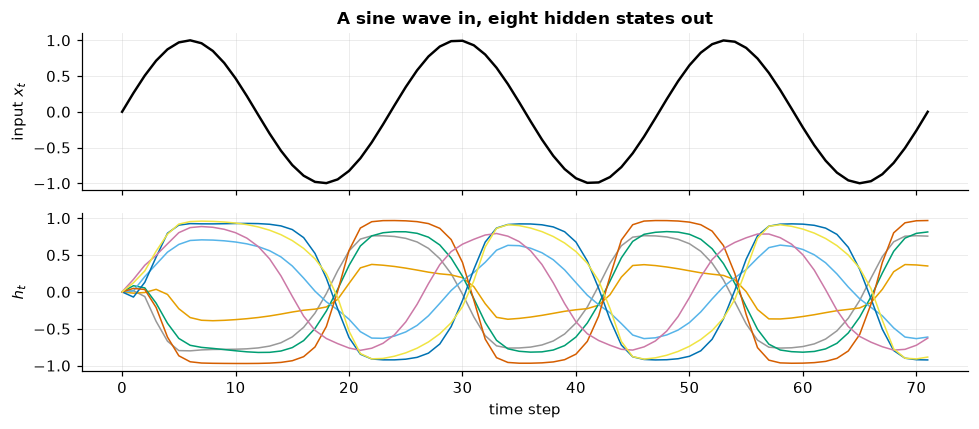

The hidden units respond at the input's frequency with different phases and
amplitudes — an untrained RNN is already a bank of filters. Training shapes it.


In [3]:
def rnn_forward_numpy(
    sequence: np.ndarray, W_x: np.ndarray, W_h: np.ndarray, b: np.ndarray
) -> np.ndarray:
    """Run a vanilla RNN over one sequence, returning every hidden state.

    ``sequence`` is ``(T, n_features)``; the result is ``(T, n_hidden)``.
    """
    n_hidden = W_h.shape[0]
    h = np.zeros(n_hidden)
    states = []
    for x_t in sequence:
        h = np.tanh(W_x @ x_t + W_h @ h + b)
        states.append(h)
    return np.stack(states)


set_seed()
rng = np.random.default_rng(0)
N_HIDDEN = 8
W_x = rng.normal(0, 0.5, size=(N_HIDDEN, 1))
W_h = rng.normal(0, 0.5, size=(N_HIDDEN, N_HIDDEN))
bias = np.zeros(N_HIDDEN)

demo_sequence = np.sin(np.linspace(0, 6 * np.pi, 72)).reshape(-1, 1)
states = rnn_forward_numpy(demo_sequence, W_x, W_h, bias)

fig, axes = plt.subplots(2, 1, figsize=(9, 4), sharex=True)
axes[0].plot(demo_sequence, color=COLORS["truth"])
axes[0].set_ylabel("input $x_t$")
axes[0].set_title("A sine wave in, eight hidden states out")
axes[1].plot(states, lw=1.0)
axes[1].set_ylabel("$h_t$")
axes[1].set_xlabel("time step")
fig.tight_layout()
plt.show()

print("The hidden units respond at the input's frequency with different phases and")
print("amplitudes — an untrained RNN is already a bank of filters. Training shapes it.")

## 6. Measuring the vanishing gradient

Rather than assert that gradients vanish, compute $\lvert \partial h_T /
\partial x_t \rvert$ for every $t$ and watch it decay. Autograd makes this
three lines.

The comparison includes **three** models on purpose, because the naive
two-model version of this experiment gives a misleading answer:

1. a vanilla RNN;
2. an LSTM with PyTorch's default initialisation;
3. the same LSTM with its **forget-gate bias set to +2**.

The third is not a trick to win the plot. With a forget-gate bias of zero the
gate sits near $\sigma(0) = 0.5$, so the cell state is halved at every step
and decays as fast as anything else — an untrained LSTM has no long memory.
The architecture only makes long memory *reachable*; the gate has to be open
for the path to exist. Initialising the forget-gate bias positive is standard
practice for exactly this reason (Jozefowicz et al., 2015), and it is the
clearest possible illustration that gates are learned, not given.

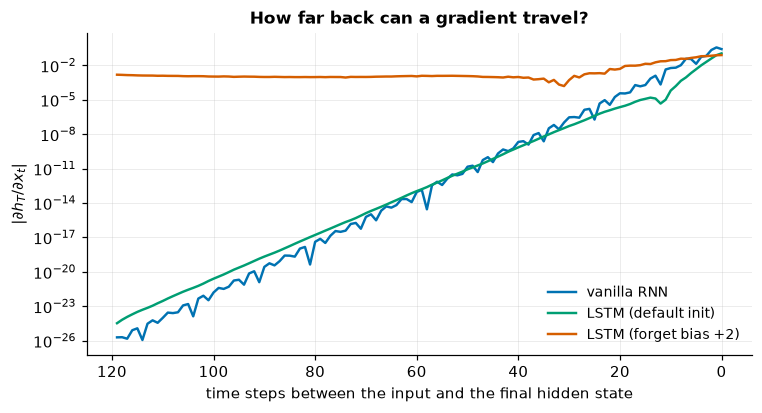

Sensitivity to an input 120 steps back, relative to the most recent one:

  vanilla RNN              7.36e-26
  LSTM (default init)      2.99e-24
  LSTM (forget bias +2)    1.94e-02

Read it in this order:
  * The vanilla RNN's gradient is numerically zero 120 steps back. Nothing about
    an input that far away can ever be learned.
  * The default-initialised LSTM is no better — and on this run it may be worse.
    A closed forget gate multiplies the cell state by ~0.5 every step.
  * Opening the forget gate restores the long path by many orders of magnitude.

The architecture does not give you long memory. It gives you a *route* to long
memory that gradient descent can find, and a sensible initialisation puts the
model on that route from the start. This is why forget-gate bias initialisation
is a standard trick and not a footnote.

(All three networks are untrained, so this is a property of the architecture
and its initialisation, not of anything they have learned.)


In [4]:
set_seed()
SEQ_LENGTH = 120


def input_sensitivity(module: nn.Module) -> np.ndarray:
    """|d h_T / d x_t| for every t, via one backward pass.

    Driven with a real (random) signal rather than zeros, so the gates are
    actually exercised instead of sitting at their bias values.
    """
    torch.manual_seed(0)
    inputs = torch.randn(1, SEQ_LENGTH, 1) * 0.5
    inputs.requires_grad_(True)
    output, *_ = module(inputs)
    output[0, -1, :].sum().backward()
    return inputs.grad[0, :, 0].abs().detach().numpy()


torch.manual_seed(0)
vanilla = nn.RNN(input_size=1, hidden_size=32, batch_first=True, nonlinearity="tanh")
torch.manual_seed(0)
lstm_default = nn.LSTM(input_size=1, hidden_size=32, batch_first=True)
torch.manual_seed(0)
lstm_open = nn.LSTM(input_size=1, hidden_size=32, batch_first=True)

# PyTorch packs the LSTM biases as [input, forget, cell, output], each of size
# hidden_size. The forget gate is therefore the second block.
with torch.no_grad():
    hidden_size = 32
    for bias_name in ("bias_ih_l0", "bias_hh_l0"):
        bias = getattr(lstm_open, bias_name)
        bias[hidden_size : 2 * hidden_size].fill_(1.0)   # +1 in each of the two biases -> +2

sensitivities = {
    "vanilla RNN": input_sensitivity(vanilla),
    "LSTM (default init)": input_sensitivity(lstm_default),
    "LSTM (forget bias +2)": input_sensitivity(lstm_open),
}

fig, ax = plt.subplots(figsize=(7.8, 3.8))
steps_back = np.arange(SEQ_LENGTH)[::-1]
palette = {
    "vanilla RNN": COLORS["rnn"],
    "LSTM (default init)": COLORS["tree"],
    "LSTM (forget bias +2)": COLORS["transformer"],
}
for label, gradient in sensitivities.items():
    ax.semilogy(steps_back, np.maximum(gradient, 1e-38), label=label, color=palette[label])
ax.set_xlabel("time steps between the input and the final hidden state")
ax.set_ylabel(r"$|\partial h_T / \partial x_t|$")
ax.set_title("How far back can a gradient travel?")
ax.invert_xaxis()
ax.legend()
plt.show()

print(f"Sensitivity to an input {SEQ_LENGTH} steps back, relative to the most recent one:\n")
for label, gradient in sensitivities.items():
    ratio = gradient[0] / max(gradient[-1], 1e-38)
    print(f"  {label:24s} {ratio:.2e}")

print("\nRead it in this order:")
print("  * The vanilla RNN's gradient is numerically zero 120 steps back. Nothing about")
print("    an input that far away can ever be learned.")
print("  * The default-initialised LSTM is no better — and on this run it may be worse.")
print("    A closed forget gate multiplies the cell state by ~0.5 every step.")
print("  * Opening the forget gate restores the long path by many orders of magnitude.")
print("\nThe architecture does not give you long memory. It gives you a *route* to long")
print("memory that gradient descent can find, and a sensible initialisation puts the")
print("model on that route from the start. This is why forget-gate bias initialisation")
print("is a standard trick and not a footnote.")
print("\n(All three networks are untrained, so this is a property of the architecture")
print("and its initialisation, not of anything they have learned.)")

## 7. Power-system application

Same benchmark as tutorials 01 and 02 — **load at t+24** — but the models now
receive a raw 168-hour window instead of a hand-picked list of lags.

In [5]:
CONTEXT = 168     # one week of history
HORIZON = 24      # predict the next 24 hours; we score the 24th
frame = load_energy_data().frame
train_raw, valid_raw, test_raw = time_split(frame)

CHANNELS = ["load_mw", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "temperature_c"]


def channel_frame(part: pd.DataFrame) -> pd.DataFrame:
    """Build the model's input channels. Calendar terms only, no lag engineering."""
    out = pd.DataFrame(index=part.index)
    out["load_mw"] = part.load_mw
    out["hour_sin"] = np.sin(2 * np.pi * part.index.hour / 24)
    out["hour_cos"] = np.cos(2 * np.pi * part.index.hour / 24)
    out["dow_sin"] = np.sin(2 * np.pi * part.index.dayofweek / 7)
    out["dow_cos"] = np.cos(2 * np.pi * part.index.dayofweek / 7)
    out["temperature_c"] = part.temperature_c
    return out


def build_windows(part: pd.DataFrame, history: pd.DataFrame | None = None):
    """Windows for one split, with ``history`` supplying the leading context.

    Without the history hand-over the first ``CONTEXT`` timestamps of a split
    could not be predicted at all, and the splits would not be comparable with
    the tabular models of tutorials 01 and 02, which *can* predict them.
    """
    channels = channel_frame(part)
    if history is not None:
        channels = pd.concat([channel_frame(history).tail(CONTEXT), channels])
    x, y = make_windows(
        channels["load_mw"], context=CONTEXT, horizon=HORIZON,
        covariates=channels.drop(columns="load_mw"),
    )
    # Timestamp of the *last* predicted hour, i.e. origin + HORIZON.
    target_index = channels.index[CONTEXT + HORIZON - 1 : len(channels)]
    return x, y, target_index[: len(y)]


x_train, y_train, idx_train = build_windows(train_raw)
x_valid, y_valid, idx_valid = build_windows(valid_raw, history=train_raw)
x_test, y_test_seq, idx_test = build_windows(test_raw, history=valid_raw)

print(f"x_train {x_train.shape}  (windows, hours of context, channels)")
print(f"y_train {y_train.shape}  (windows, hours of horizon)")
print(f"channels: {CHANNELS}")
print(f"\ntest windows span {idx_test[0]:%Y-%m-%d} to {idx_test[-1]:%Y-%m-%d}")

# The leaderboard target is the 24th step, which is exactly tutorial 01's
# `load_mw_t+24`. The full horizon is reported separately.
y_test_point = y_test_seq[:, -1]

x_train (17329, 168, 6)  (windows, hours of context, channels)
y_train (17329, 24)  (windows, hours of horizon)
channels: ['load_mw', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'temperature_c']

test windows span 2020-01-01 to 2020-12-31


In [6]:
# Standardise per channel, fitted on training windows only.
scaler = Standardizer().fit(x_train.reshape(-1, x_train.shape[2]), axis=0)
xs_train = scaler.transform(x_train.reshape(-1, x_train.shape[2])).reshape(x_train.shape)
xs_valid = scaler.transform(x_valid.reshape(-1, x_valid.shape[2])).reshape(x_valid.shape)
xs_test = scaler.transform(x_test.reshape(-1, x_test.shape[2])).reshape(x_test.shape)

target_scaler = Standardizer().fit(y_train)
ys_train = target_scaler.transform(y_train)
ys_valid = target_scaler.transform(y_valid)

print(f"load channel: mean {scaler.mean_[0, 0]:,.0f} MW, std {scaler.std_[0, 0]:,.0f} MW")

load channel: mean 54,946 MW, std 6,911 MW


### 7.1 Non-neural references on the *same* windows

A linear autoregression and gradient boosting, both fed the flattened window.
This keeps the comparison about architecture rather than about who saw which
data.

In [7]:
flat_train = xs_train.reshape(len(xs_train), -1)
flat_valid = xs_valid.reshape(len(xs_valid), -1)
flat_test = xs_test.reshape(len(xs_test), -1)
print(f"flattened window: {flat_train.shape[1]:,} features per example")

set_seed()
ridge = Ridge(alpha=10.0).fit(flat_train, ys_train)
ridge_prediction = target_scaler.inverse_transform(ridge.predict(flat_test))

# Gradient boosting cannot emit 24 outputs at once, and fitting 24 separate
# models on 1,008 features is slow, so it gets the load channel only and
# predicts the single point target. Noted because it is a real limitation of
# the method, not a handicap we imposed for fun.
boost_train_x = x_train[:, :, 0]
boost_test_x = x_test[:, :, 0]
boosting = HistGradientBoostingRegressor(
    max_iter=scaled(full=300, fast=50), learning_rate=0.06, random_state=0
).fit(boost_train_x, y_train[:, -1])
boosting_prediction = boosting.predict(boost_test_x)

print(f"Ridge on flattened window   MAE (t+24): {mae(y_test_point, ridge_prediction[:, -1]):,.1f} MW")
print(f"Gradient boosting on window MAE (t+24): {mae(y_test_point, boosting_prediction):,.1f} MW")

flattened window: 1,008 features per example


Ridge on flattened window   MAE (t+24): 1,749.8 MW
Gradient boosting on window MAE (t+24): 1,790.2 MW


### 7.2 Three neural architectures, identical data

In [8]:
def train_sequence_model(model: nn.Module, label: str, epochs: int, learning_rate: float = 1e-3):
    """Train one sequence model on the shared windows and score it."""
    set_seed()
    started = time.perf_counter()
    history = train_model(
        model,
        make_loader(xs_train, ys_train, batch_size=64, shuffle=True),
        make_loader(xs_valid, ys_valid, batch_size=256),
        loss_fn=nn.MSELoss(),
        config=TrainConfig(
            epochs=epochs, learning_rate=learning_rate, patience=6, verbose=False
        ),
    )
    seconds = time.perf_counter() - started
    prediction = target_scaler.inverse_transform(predict(model, xs_test))
    print(f"{label:24s} params {count_parameters(model):7,}  "
          f"best epoch {history.best_epoch:3d}  {seconds:6.1f}s  "
          f"MAE(t+24) {mae(y_test_point, prediction[:, -1]):8,.1f} MW  "
          f"MAE(1-24h) {mae(y_test_seq.ravel(), prediction.ravel()):8,.1f} MW")
    return prediction, history, seconds


EPOCHS = scaled(full=40, fast=2)
n_channels = xs_train.shape[2]

set_seed()
mlp = MLPForecaster(CONTEXT, HORIZON, n_channels=n_channels, hidden_sizes=(128, 64))
mlp_prediction, mlp_history, mlp_seconds = train_sequence_model(mlp, "MLP (flattened window)", EPOCHS)

set_seed()
simple_rnn = SimpleRNNForecaster(n_channels, hidden_size=64, horizon=HORIZON)
rnn_prediction, rnn_history, rnn_seconds = train_sequence_model(
    simple_rnn, "Vanilla RNN", EPOCHS)

set_seed()
lstm = LSTMForecaster(n_channels, hidden_size=64, num_layers=1, horizon=HORIZON)
lstm_prediction, lstm_history, lstm_seconds = train_sequence_model(lstm, "LSTM", EPOCHS)

MLP (flattened window)   params 138,968  best epoch  15    10.8s  MAE(t+24)  1,834.4 MW  MAE(1-24h)  1,498.3 MW


Vanilla RNN              params   6,104  best epoch  24   145.0s  MAE(t+24)  1,686.1 MW  MAE(1-24h)  1,389.7 MW


LSTM                     params  19,992  best epoch  16    88.9s  MAE(t+24)  1,639.3 MW  MAE(1-24h)  1,361.8 MW


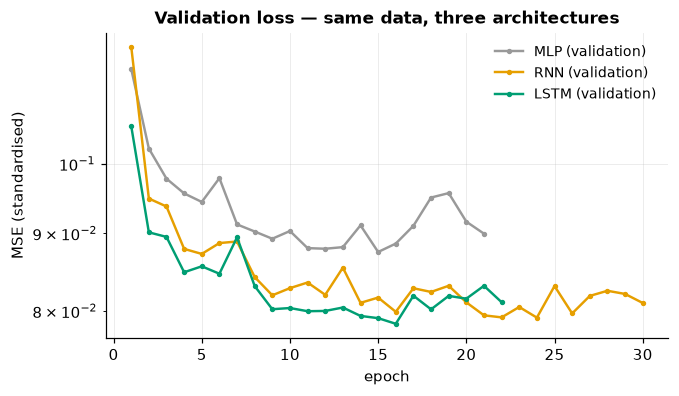

In [9]:
fig, ax = plt.subplots(figsize=(6.6, 3.6))
plot_learning_curve(
    {
        "MLP (validation)": mlp_history.val_loss,
        "RNN (validation)": rnn_history.val_loss,
        "LSTM (validation)": lstm_history.val_loss,
    },
    title="Validation loss — same data, three architectures",
    ylabel="MSE (standardised)",
    ax=ax,
)
plt.show()

## 8. Baseline comparison

Everything on the identical test windows, scored two ways: the single point at
$t+24$ (comparable with tutorials 01 and 02) and the whole 1–24 h horizon.

In [10]:
# Index arithmetic, spelled out, because this is exactly where alignment bugs
# live. Context position i holds the value at time origin - 167 + i, and the
# target is at origin + HORIZON.
ORIGIN_POSITION = CONTEXT - 1                                   # = 167
persistence_point = x_test[:, ORIGIN_POSITION, 0]               # load[origin]
weekly_point = x_test[:, ORIGIN_POSITION - (168 - HORIZON), 0]  # load[target - 168 h]

# Cross-check against the raw frame rather than trusting the arithmetic.
_probe = frame.load_mw.reindex(idx_test)
assert np.allclose(persistence_point, frame.load_mw.reindex(idx_test - pd.Timedelta(hours=HORIZON)))
assert np.allclose(weekly_point, frame.load_mw.reindex(idx_test - pd.Timedelta(hours=168)))
print("window-index baselines verified against the raw series")

point_predictions = {
    "Persistence (= seasonal naive 24 h)": persistence_point,
    "Seasonal naive (168 h)": weekly_point,
    "Ridge on window": ridge_prediction[:, -1],
    "Gradient boosting": boosting_prediction,
    "MLP (flattened)": mlp_prediction[:, -1],
    "Vanilla RNN": rnn_prediction[:, -1],
    "LSTM": lstm_prediction[:, -1],
}

reference = point_predictions["Seasonal naive (168 h)"]
results = pd.DataFrame(
    {
        name: {
            **point_metrics(y_test_point, values),
            "Skill": skill_score(y_test_point, values, reference),
        }
        for name, values in point_predictions.items()
    }
).T.sort_values("MAE")
display(results.round(3))

window-index baselines verified against the raw series


,MAE,RMSE,R2,Bias,MAPE_%,Skill
LSTM,1639.269,2260.473,0.890,475.708,3.083,0.251
Vanilla RNN,1686.095,2296.802,0.886,568.151,3.189,0.239
Ridge on window,1749.824,2318.048,0.884,248.351,3.291,0.232
Gradient boosting,1790.248,2400.914,0.875,116.781,3.356,0.205
MLP (flattened),1834.358,2410.513,0.874,859.732,3.471,0.201
Seasonal naive (168 h),2262.963,3018.770,0.803,-20.707,4.197,0.000
Persistence (= seasonal naive 24 h),3355.265,4590.985,0.545,6.533,6.356,-0.521


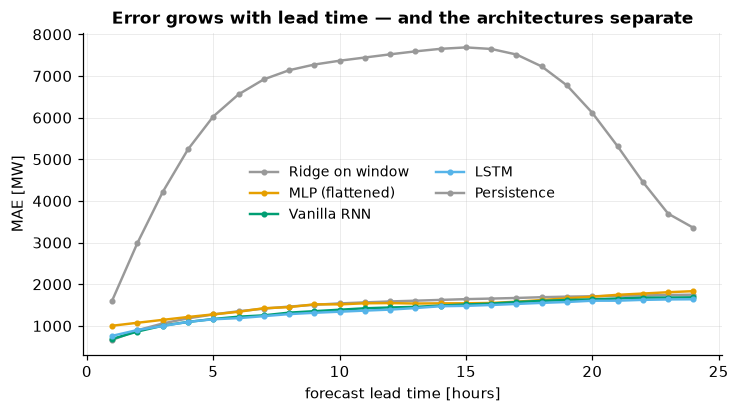

,Ridge on window,MLP (flattened),Vanilla RNN,LSTM,Persistence
1,661.5,1003.9,686.5,761.4,1608.4
6,1352.0,1338.9,1221.3,1186.0,6557.9
12,1587.5,1547.7,1442.8,1391.4,7520.0
18,1689.4,1620.7,1600.5,1553.1,7229.0
24,1749.8,1834.4,1686.1,1639.3,3355.3


In [11]:
horizon_predictions = {
    "Ridge on window": ridge_prediction,
    "MLP (flattened)": mlp_prediction,
    "Vanilla RNN": rnn_prediction,
    "LSTM": lstm_prediction,
}
per_step = pd.DataFrame(
    {name: [mae(y_test_seq[:, h], values[:, h]) for h in range(HORIZON)]
     for name, values in horizon_predictions.items()},
    index=np.arange(1, HORIZON + 1),
)
# A persistence forecast for the whole horizon: repeat the last observed value.
per_step["Persistence"] = [
    mae(y_test_seq[:, h], x_test[:, ORIGIN_POSITION, 0]) for h in range(HORIZON)
]

fig, ax = plt.subplots(figsize=(7.5, 3.8))
for name in per_step.columns:
    ax.plot(per_step.index, per_step[name], marker="o", ms=3, label=name,
            color=COLORS["baseline"] if name == "Persistence" else None)
ax.set_xlabel("forecast lead time [hours]")
ax.set_ylabel("MAE [MW]")
ax.set_title("Error grows with lead time — and the architectures separate")
ax.legend(ncol=2)
plt.show()

display(per_step.iloc[[0, 5, 11, 17, 23]].round(1))

The per-lead-time curve is the single most useful plot in energy forecasting
and the aggregate MAE hides all of it. At one hour ahead persistence is nearly
unbeatable and every model is within noise of it; by 24 hours the gap is large.
A paper that reports one number for "the forecast error" has thrown this away.

## 9. Inspect the model

What is inside the LSTM's hidden state?

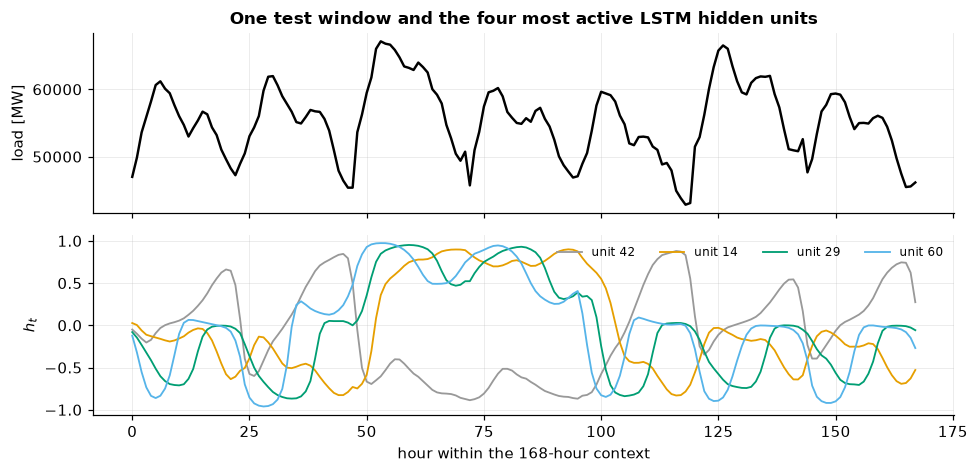

Hidden units correlated with a 24-hour sine (|r| > 0.5): 29 of 64
Some units have become daily-cycle detectors without ever being told that a day
has 24 hours. Nobody engineered `hour_sin` into the recurrence — it emerged.


In [12]:
with torch.no_grad():
    sample_batch = torch.tensor(xs_test[:200], dtype=torch.float32)
    _, sequence_output = lstm(sample_batch, return_sequence=True)
hidden = sequence_output[0].numpy()          # (context, hidden_size)

variance = hidden.var(axis=0)
busiest = np.argsort(variance)[-4:]

fig, axes = plt.subplots(2, 1, figsize=(9, 4.4), sharex=True)
axes[0].plot(x_test[0, :, 0], color=COLORS["truth"])
axes[0].set_ylabel("load [MW]")
axes[0].set_title("One test window and the four most active LSTM hidden units")
for unit in busiest:
    axes[1].plot(hidden[:, unit], lw=1.2, label=f"unit {unit}")
axes[1].set_xlabel("hour within the 168-hour context")
axes[1].set_ylabel("$h_t$")
axes[1].legend(ncol=4, fontsize=8)
fig.tight_layout()
plt.show()

daily = np.corrcoef(hidden.T, np.sin(2 * np.pi * np.arange(CONTEXT) / 24))[:-1, -1]
print(f"Hidden units correlated with a 24-hour sine (|r| > 0.5): "
      f"{int((np.abs(daily) > 0.5).sum())} of {hidden.shape[1]}")
print("Some units have become daily-cycle detectors without ever being told that a day")
print("has 24 hours. Nobody engineered `hour_sin` into the recurrence — it emerged.")

## 10. Failure analysis

Two candidate explanations for when the LSTM struggles, one of which turns out
to be wrong. That is the point of the section.

- **Hypothesis A:** the model does badly after a *volatile* stretch, because
  the recent past is a poor guide.
- **Hypothesis B:** the model does badly when the *target hour itself* is
  unusual for its calendar slot — a cold snap, a holiday, an atypical weekday.

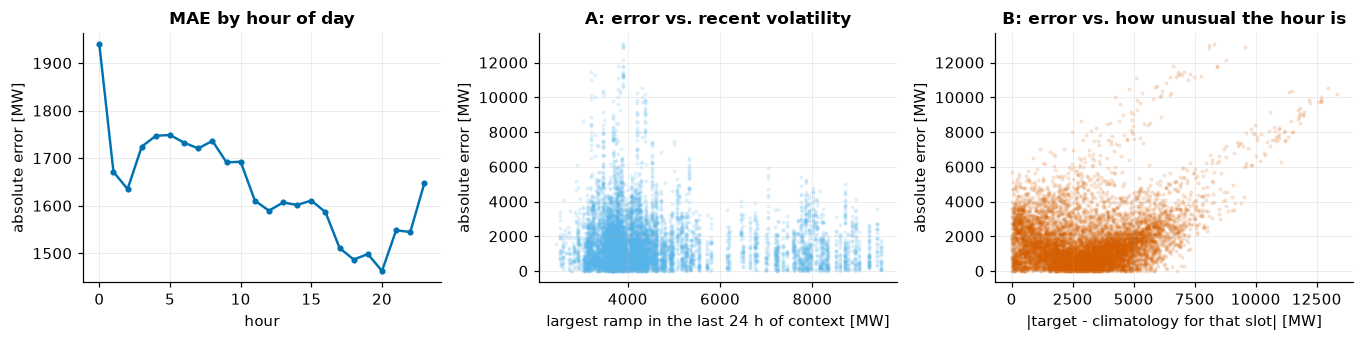

In [13]:
lstm_point = lstm_prediction[:, -1]

# "How volatile was the recent past?" — largest hourly ramp in the last day of context.
recent_volatility = np.abs(np.diff(x_test[:, -24:, 0], axis=1)).max(axis=1)

# "How unusual is the target hour?" — deviation from the training climatology
# for that (hour, weekday) slot. Uses only training data, so it is leak-free.
profile = train_raw.load_mw.groupby(
    [train_raw.index.hour, train_raw.index.dayofweek]
).mean()
expected = np.array([
    profile.get((h, d), float(train_raw.load_mw.mean()))
    for h, d in zip(idx_test.hour, idx_test.dayofweek, strict=True)
])
unusualness = np.abs(y_test_point - expected)

errors = pd.DataFrame(
    {
        "absolute_error": np.abs(lstm_point - y_test_point),
        "observed": y_test_point,
        "hour": idx_test.hour,
        "month": idx_test.month,
        "recent_volatility": recent_volatility,
        "unusualness": unusualness,
    },
    index=idx_test,
)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.2))
errors.groupby("hour").absolute_error.mean().plot(
    ax=axes[0], marker="o", ms=3, color=COLORS["rnn"], title="MAE by hour of day")
axes[1].scatter(errors.recent_volatility, errors.absolute_error, s=3, alpha=0.12,
                color=COLORS["mlp"])
axes[1].set_xlabel("largest ramp in the last 24 h of context [MW]")
axes[1].set_title("A: error vs. recent volatility")
axes[2].scatter(errors.unusualness, errors.absolute_error, s=3, alpha=0.12,
                color=COLORS["transformer"])
axes[2].set_xlabel("|target - climatology for that slot| [MW]")
axes[2].set_title("B: error vs. how unusual the hour is")
for ax in axes:
    ax.set_ylabel("absolute error [MW]")
fig.tight_layout()
plt.show()

In [14]:
for label, column in [("A  recent volatility", "recent_volatility"),
                      ("B  unusualness of the target", "unusualness")]:
    correlation = errors[[column, "absolute_error"]].corr().iloc[0, 1]
    low = errors[errors[column] < errors[column].quantile(0.25)].absolute_error.mean()
    high = errors[errors[column] > errors[column].quantile(0.75)].absolute_error.mean()
    print(f"{label:32s} r = {correlation:+.3f}   "
          f"MAE bottom quartile {low:6,.0f} MW  ->  top quartile {high:6,.0f} MW")

print("\nHypothesis A does not survive contact with the data: recent volatility barely")
print("predicts the error, and if anything points the wrong way. A plausible reason is")
print("that the most volatile stretches here are winter weekdays with a large, highly")
print("*regular* daily swing — volatile and predictable are not the same thing.")
print("\nHypothesis B does survive, and by a wide margin. The model is a very good")
print("climatology-plus-recent-history machine, and it fails exactly where that")
print("description breaks down: on hours that do not look like their calendar slot.")
print("\nThis is worth internalising. The intuitive diagnostic was the wrong one, and")
print("only measuring both told us so. Report the hypothesis that failed, too.")

A  recent volatility             r = -0.073   MAE bottom quartile  1,698 MW  ->  top quartile  1,459 MW
B  unusualness of the target     r = +0.282   MAE bottom quartile  1,768 MW  ->  top quartile  2,344 MW

Hypothesis A does not survive contact with the data: recent volatility barely
predicts the error, and if anything points the wrong way. A plausible reason is
that the most volatile stretches here are winter weekdays with a large, highly
*regular* daily swing — volatile and predictable are not the same thing.

Hypothesis B does survive, and by a wide margin. The model is a very good
climatology-plus-recent-history machine, and it fails exactly where that
description breaks down: on hours that do not look like their calendar slot.

This is worth internalising. The intuitive diagnostic was the wrong one, and
only measuring both told us so. Report the hypothesis that failed, too.


### Where the sequence models help, and where they do not

In [15]:
best_point = results.index[0]
lstm_mae = results.loc["LSTM", "MAE"]
mlp_mae = results.loc["MLP (flattened)", "MAE"]
rnn_mae = results.loc["Vanilla RNN", "MAE"]

print(f"Best on this benchmark: {best_point}")
print(f"  LSTM        {lstm_mae:8,.1f} MW   ({lstm_seconds:.0f}s to train)")
print(f"  Vanilla RNN {rnn_mae:8,.1f} MW   ({rnn_seconds:.0f}s)")
print(f"  MLP         {mlp_mae:8,.1f} MW   ({mlp_seconds:.0f}s)")
print(f"\nLSTM vs. vanilla RNN : {1 - lstm_mae / rnn_mae:+.1%}")
print(f"LSTM vs. flat MLP    : {1 - lstm_mae / mlp_mae:+.1%}")
print("\nNote how modest the architectural gain is at a 168-hour context. The gating")
print("machinery earns its keep on *long* dependencies; a week of hourly data is not")
print("long enough for the vanilla RNN to fall apart completely, and the MLP can")
print("simply look at all 168 inputs at once — at the cost of 1,008 input weights")
print("that are specific to this exact window length.")

Best on this benchmark: LSTM
  LSTM         1,639.3 MW   (89s to train)
  Vanilla RNN  1,686.1 MW   (145s)
  MLP          1,834.4 MW   (11s)

LSTM vs. vanilla RNN : +2.8%
LSTM vs. flat MLP    : +10.6%

Note how modest the architectural gain is at a 168-hour context. The gating
machinery earns its keep on *long* dependencies; a week of hourly data is not
long enough for the vanilla RNN to fall apart completely, and the MLP can
simply look at all 168 inputs at once — at the cost of 1,008 input weights
that are specific to this exact window length.


## 11. Record the result

In [16]:
Leaderboard().clear(tutorial=3)
for name, module, prediction, seconds in [
    ("LSTM", lstm, lstm_prediction, lstm_seconds),
    ("Vanilla RNN", simple_rnn, rnn_prediction, rnn_seconds),
]:
    record(
        model=name,
        tutorial=3,
        metrics={
            **point_metrics(y_test_point, prediction[:, -1]),
            "Skill": skill_score(y_test_point, prediction[:, -1], reference),
        },
        n_parameters=count_parameters(module),
        train_seconds=seconds,
        notes=f"raw {CONTEXT} h window, {n_channels} channels",
    )
display(leaderboard_table())

print("\nA caveat worth stating out loud: the tutorial 01 and 02 models were given")
print("hand-engineered rolling statistics that the sequence models were not. The")
print("comparison is between *approaches*, not a controlled ablation of architecture.")

Bias       MAE  \
Tutorial Model                                                           
2        MLP (2 hidden layers)                        72.396  1624.032   
1        Random forest                               228.205  1636.504   
3        LSTM                                        475.708  1639.269   
         Vanilla RNN                                 568.151  1686.095   
1        Gradient boosting                           574.800  1776.462   
         Linear regression                           359.230  2066.153   
         seasonal naive (168 h)                       51.785  2218.972   
         climatology (hour x weekday)                973.565  3092.499   
         persistence (h=24) = seasonal naive (24 h)   30.224  3358.186   

                                                     MAPE_%     R2      RMSE  \
Tutorial Model                                                                 
2        MLP (2 hidden layers)                        3.047  0.896  2190.210   
1        Random forest                                3.067  0.889  2260.824   
3        LSTM                                         3.083  0.890  2260.473   
         Vanilla RNN                                  3.189  0.886  2296.802   
1        Gradient boosting                            3.345  0.875  2400.515   
         Linear regression                            3.892  0.847  2651.899   
         seasonal naive (168 h)                       4.130  0.811  2952.957   
         climatology (hour x weekday)                 5.864  0.715  3623.821   
         persistence (h=24) = seasonal naive (24 h)   6.372  0.541  4600.202   

                                                     Skill  \
Tutorial Model                                               
2        MLP (2 hidden layers)                       0.258   
1        Random forest                               0.234   
3        LSTM                                        0.251   
         Vanilla RNN                                 0.239   
1        Gradient boosting                           0.187   
         Linear regression                           0.102   
         seasonal naive (168 h)                      0.000   
         climatology (hour x weekday)               -0.227   
         persistence (h=24) = seasonal naive (24 h) -0.558   

                                                                                       Notes  \
Tutorial Model                                                                                 
2        MLP (2 hidden layers)                       same engineered features as tutorial 01   
1        Random forest                                    engineered lag + calendar features   
3        LSTM                                                   raw 168 h window, 6 channels   
         Vanilla RNN                                            raw 168 h window, 6 channels   
1        Gradient boosting                                engineered lag + calendar features   
         Linear regression                                engineered lag + calendar features   
         seasonal naive (168 h)                                             trivial baseline   
         climatology (hour x weekday)                                       trivial baseline   
         persistence (h=24) = seasonal naive (24 h)                         trivial baseline   

                                                      Params  Train_s  
Tutorial Model                                                         
2        MLP (2 hidden layers)                       11777.0      6.2  
1        Random forest                                   NaN      NaN  
3        LSTM                                        19992.0     88.9  
         Vanilla RNN                                  6104.0    145.0  
1        Gradient boosting                               NaN      NaN  
         Linear regression                               NaN      NaN  
         seasonal naive (168 h)             


A caveat worth stating out loud: the tutorial 01 and 02 models were given
hand-engineered rolling statistics that the sequence models were not. The
comparison is between *approaches*, not a controlled ablation of architecture.


## 12. Exercises

**1 — Conceptual.** Tutorial 01 left one confound unresolved: its chronological
test set was both *held out* and *later in time*, so leakage and distribution
drift were tangled together. Design and run the third comparison that
separates them — a random split *within* the training period — and report how
much of tutorial 01's gap was leakage and how much was drift. State what you
expect before you run it.

**2 — Coding.** The vanilla RNN and the LSTM were given a 168-hour context.
Re-run both at contexts of 24, 72, 168 and 336 hours and plot MAE against
context length for each. At what length does the vanilla RNN stop improving,
and does the LSTM keep going? Relate your answer to the gradient-decay curve
in section 6. (Watch the training time: the recurrent loop is sequential, so
it scales linearly with context.)

**3 — Research.** Both sequence models predict all 24 hours in one shot
("direct" multi-horizon). The alternative is *recursive* forecasting: predict
one step, append it to the input, predict again. Implement the recursive
variant with the same trained LSTM and compare the per-lead-time error curves.
Explain the shape difference in terms of error accumulation, and say which you
would deploy for a day-ahead market bid and why.

## 13. Key takeaways

- **An RNN shares one set of weights across time**, so the parameter count is
  independent of the sequence length and the architecture — not the feature
  list — encodes order.
- **Gradients decay geometrically through a vanilla recurrence.** We measured
  it: the influence of an input 120 steps back was numerically zero.
- **The LSTM's additive cell state keeps that path open**, which is why it
  displaced vanilla RNNs everywhere and held the field for two decades.
- **Error grows with lead time, and the models separate as it does.** Always
  plot error against horizon; a single aggregate number conceals the result.
- **Architectural gains here were modest**, because one week of hourly data is
  not a long dependency. The real cost of the recurrence is that it is
  *sequential*: 168 steps must be computed one after another, and that cannot
  be parallelised. Tutorial 05 removes exactly that constraint.

## 14. Further reading

- Hochreiter & Schmidhuber, "Long Short-Term Memory", *Neural Computation*
  9(8), 1997.
- Bengio, Simard & Frasconi, "Learning long-term dependencies with gradient
  descent is difficult", *IEEE Trans. Neural Networks* 5(2), 1994.
- Olah, "Understanding LSTM Networks" (2015) — the diagrams everyone uses.
  <https://colah.github.io/posts/2015-08-Understanding-LSTMs/>
- Sutskever, Vinyals & Le, "Sequence to Sequence Learning with Neural
  Networks", [arXiv:1409.3215](https://arxiv.org/abs/1409.3215).
- Hewamalage, Bergmeir & Bandara, "Recurrent Neural Networks for Time Series
  Forecasting: Current status and future directions", *IJF* 37(1), 2021 —
  a sober assessment of RNNs against statistical baselines on real data.

---

**Next:** [Tutorial 04 — Representation Learning, Embeddings and
Self-Supervision](04_representation_learning.ipynb). We stop training for a
task at all, and see what the model learns when nobody gives it labels.